# Vertebral Column dataset


In [1]:
## Importing
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
from evclust.utils import plotting, display_results_fuzzy_partition, display_results_evidential
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from ucimlrepo import fetch_ucirepo
import math

from evclust.ecm import ecm
from evclust.wecm_new_barycenter import wecm
from evclust.wecm_new_barycenter_2 import wecm as wecm2
from evclust.gwecm import gwecm
from evclust.fcm.fcm_keller2000 import fcm as fcm_keller2000
from evclust.fcm.fcm_wang2004 import fcm as fcm_wang2004
from evclust.fcm.fcm_frigui2004 import scad1
from evclust.fcm.fcm_frigui2004 import scad2
from evclust.fcm.ifwfcm_xing2014 import fcm as ifwfcm_xing2014
from evclust.fcm.ifwfcm_kd_xing2014 import fcm as ifwfcm_kd_xing2014

Instances 310 - Features 6 - Class 3
   pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
0         63.027817    22.552586              39.609117     40.475232   
1         39.056951    10.060991              25.015378     28.995960   
2         68.832021    22.218482              50.092194     46.613539   
3         69.297008    24.652878              44.311238     44.644130   
4         49.712859     9.652075              28.317406     40.060784   

   pelvic_radius  degree_spondylolisthesis  
0      98.672917                 -0.254400  
1     114.405425                  4.564259  
2     105.985135                 -3.530317  
3     101.868495                 11.211523  
4     108.168725                  7.918501  


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


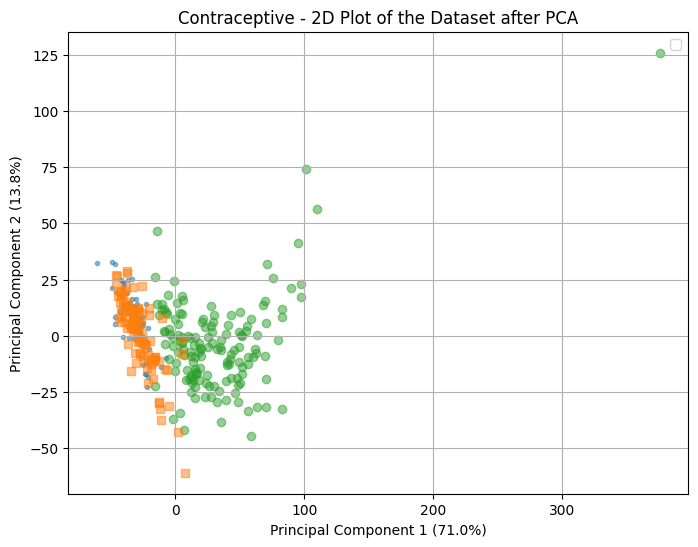

In [2]:

# fetch dataset
df = fetch_ucirepo(id=212)
X = df.data.features
y = df.data.targets

label_column_nm = y.columns[0]
labels_encoder = LabelEncoder()
numeric_labels = labels_encoder.fit_transform(y[label_column_nm])
plotting(X, y, ds_name="Contraceptive", matrix_plot=False)
c = len(np.unique(numeric_labels))

# Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(scaler.fit_transform(X))

## Traditional ECM

In [5]:
%%capture
# Traditional ECM clustering
delta = np.sqrt(20)
ecm_models = np.array([])
for i in range(10):
    model = ecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", epsi=1e-5)
    ecm_models = np.append(ecm_models, model)

ecm_models = sorted(ecm_models, key=lambda x: x['crit'])

J values: [6.942016312788195, 6.9420169639605405, 6.942017070767902, 6.942017889739327, 6.9420181405074, 6.942018863356182, 6.942019558901616, 6.942020690520425, 6.942021421508688, 6.942030710132723]
ARI values: [0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.20788758466254018]
NS values: [1.4185249762959882, 1.418770583843563, 1.4187957517049445, 1.3564655233063772, 1.4493562486795768, 1.5100100349801548, 1.3565208126396153, 1.382777434650364, 1.4187629981504826, 1.4496076036576582]
NMI values: [0.2504571304327828, 0.2504571304327828, 0.2504571304327828, 0.2504571304327828, 0.2504571304327827, 0.2504571304327828, 0.2504571304327828, 0.2504571304327828, 0.2504571304327828, 0.252849784374425]


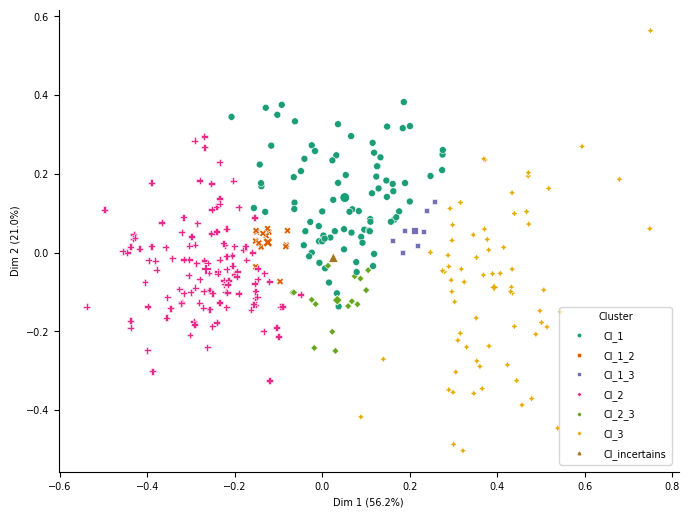

In [6]:
display_results_evidential(X, ecm_models, numeric_labels, up_low_appr=False)

## Weighted ECM (WECM)

In [7]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = wecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", stopping_factor="center")
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.051772828529029875, 0.0772804306085024, 0.07904764085479898, 0.08072524019433881, 0.084200098629825, 0.0901987980110136, 0.09379297537209977, 0.0939518446686124, 0.09529910900133892, 0.15826461784231505]
ARI values: [0.40301243587457275, 0.41986792566995057, 0.41647683445504674, 0.2752484607074382, 0.3825274384279427, 0.4161712031044782, 0.46302632087477086, 0.4133125621884396, 0.3262325476092396, 0.2639838817193994]
NS values: [1.151434085618867, 1.084621694766705, 0.7187408345239861, 1.8211401556890139, 1.0098406984202344, 1.068597007878403, 0.8127630846955043, 1.070789889148858, 1.2316957959651333, 1.3914379408277793]
NMI values: [0.5288266343536471, 0.5539953932549341, 0.541263926889007, 0.3640066177256132, 0.48730466127371797, 0.5592198776356644, 0.5599778014219097, 0.5586871498110927, 0.46649822733779867, 0.25096868128566047]


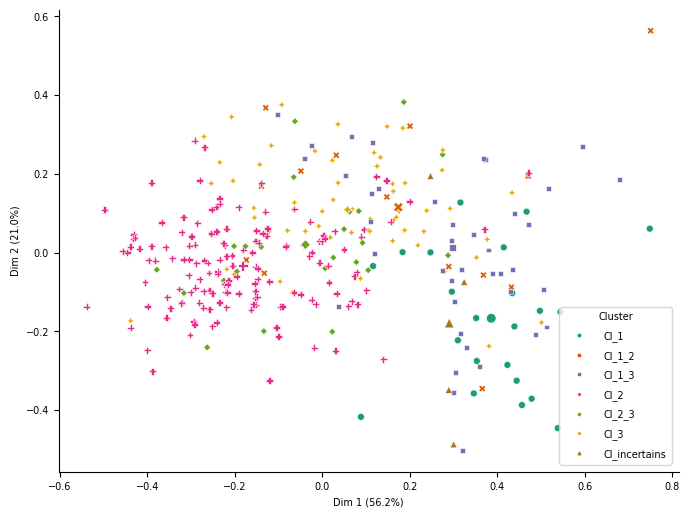

In [8]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

## WECM2

In [9]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None")
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.13958651046607895, 0.13968640224752477, 0.13970295281512535, 0.1397138708250788, 0.13973519725509623, 0.13973594396245465, 0.13986559243082386, 0.14024954127130515, 0.1680304883033824, 0.1864555227906643]
ARI values: [0.2113313529382884, 0.2113313529382884, 0.21729859385021277, 0.21729859385021277, 0.2113313529382884, 0.2113313529382884, 0.20861037088328144, 0.2014333050134229, 0.18802858030003142, 0.17470213765478199]
NS values: [1.0138683027716937, 1.3485176477337335, 1.0186968704271993, 1.2161157921876529, 1.2473303748979558, 1.0652504206793094, 1.337240853188385, 1.344648364437185, 1.5094928030056247, 1.425613688418192]
NMI values: [0.2898751797308927, 0.28987517973089266, 0.2948502632126283, 0.2948502632126283, 0.28987517973089266, 0.2898751797308927, 0.2872622748784558, 0.2815353556618629, 0.23631403252848848, 0.2277528766779966]


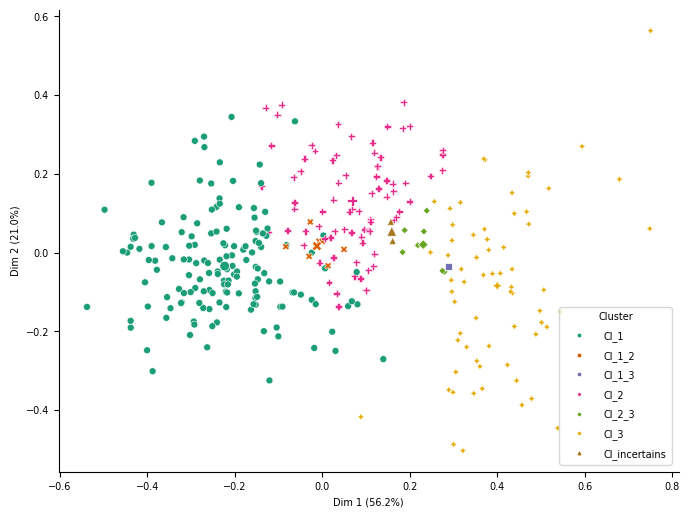

In [10]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

## Global weighted ECM - GWECM

In [7]:
%%capture
gwecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = gwecm(x=X, c=c, gamma=math.e**1, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None")
    gwecm_models = np.append(gwecm_models, model)

gwecm_models = sorted(gwecm_models, key=lambda model: model['crit'])

J values: [-3.7451461214063926, -3.7451375238135327, -3.745134668353919, -3.7450973815234825, -3.744912955107751, -3.744792647176656, -3.7444439705326085, -3.744361192878212, -3.744280871470794, -3.7440077461055803]
ARI values: [0.21531186107410913, 0.21648384210754343, 0.2159345159663644, 0.21848103028611338, 0.20615779408578558, 0.21006973451223043, 0.2062678144182398, 0.2104104043909994, 0.2062678144182398, 0.2086100518957386]
NS values: [1.4335518804414473, 1.492889746035661, 1.4957409753814443, 1.4980101917388362, 1.358797836417627, 1.401171620381307, 1.4982924293669573, 1.401605727098338, 1.4000225326636138, 1.4426319345372165]
NMI values: [0.27943437088395, 0.2848928335015843, 0.28056128589599527, 0.282636180803206, 0.275715714477119, 0.2685423761244442, 0.2670268222853058, 0.26916839180425534, 0.2670268222853058, 0.2641125900145091]


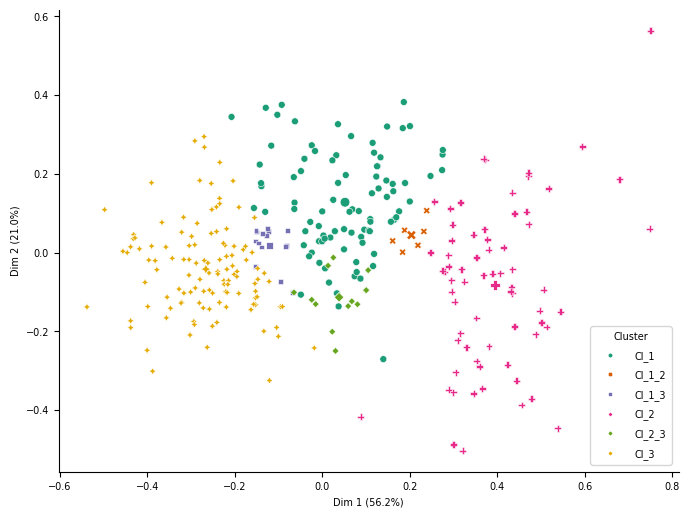

In [8]:
display_results_evidential(X, gwecm_models, numeric_labels, up_low_appr=False)

# Weighted FCM - Keller et al. 2000

In [21]:
%%capture
keller_models = np.array([])
w0 = np.ones((c, X.shape[1])) / X.shape[1]
for i in range(10):
    model = fcm_keller2000(X, c=c, w0=w0, verbose=True, epsilon=1e-7, init="None")
    keller_models = np.append(keller_models, model)
keller_models = sorted(keller_models, key=lambda model: model['obj_func'])

J values: [0.1598946288898515, 0.15989463636185947, 0.1598946460029572, 0.15989464649439167, 0.15989465083044752, 0.15989465302912387, 0.1598946684188256, 0.15989467027583334, 0.1598946726877319, 0.15989468359812167]
ARI values: [0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859]
NMI values: [0.5693200024134044, 0.5693200024134045, 0.5693200024134045, 0.5693200024134044, 0.5693200024134045, 0.5693200024134045, 0.5693200024134045, 0.5693200024134045, 0.5693200024134045, 0.5693200024134045]


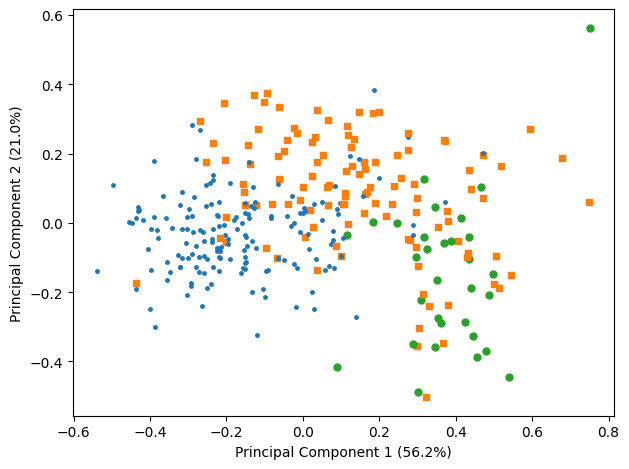

In [22]:
display_results_fuzzy_partition(X, keller_models, numeric_labels)

# Weighted FCM Wang 2004

In [15]:
%%capture
wang_models = np.array([])
for i in range(2):
    model = fcm_wang2004(X, c, w_beta=2.4, verbose=True)
    wang_models = np.append(wang_models, model)
wang_models = sorted(wang_models, key=lambda model: model['obj_func'])

J values: [0.3171220427944967, 0.3171220427944967]
ARI values: [0.21710253825862197, 0.21710253825862197]
NMI values: [0.2759028519729139, 0.2759028519729139]


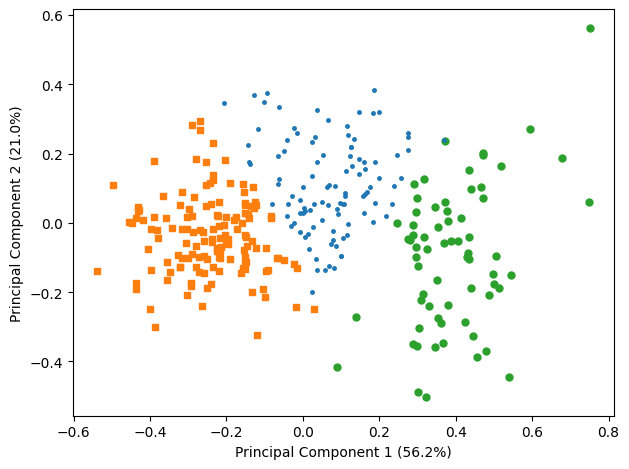

In [16]:
display_results_fuzzy_partition(X, wang_models, numeric_labels)

# SCAD1

In [13]:
%%capture
scad1_models = np.array([])
for i in range(10):
    model = scad1(X, c, verbose=True, K=2, epsilon=1e-6, init="None", stop_factor="Center")
    scad1_models = np.append(scad1_models, model)
scad1_models = sorted(scad1_models, key=lambda model: model['obj_func'])


J values: [5.338843047610874, 5.338843089294267, 5.338843170964653, 5.33884327918403, 5.3388434478788795, 5.338843590088828, 5.338847667037561, 5.338847908817394, 5.338848062310874, 5.338848087071609]
ARI values: [0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125]
NMI values: [0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253]


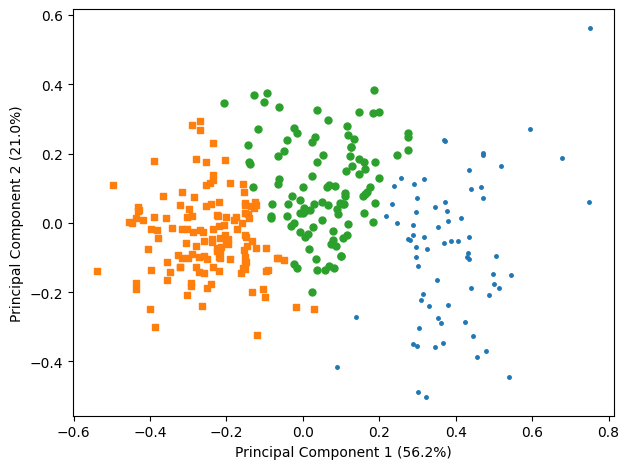

In [14]:
display_results_fuzzy_partition(X, scad1_models, numeric_labels)

# SCAD2

In [15]:
%%capture
scad2_models = np.array([])
for i in range(10):
    model = scad2(X, c, verbose=True, init="None", epsilon=1e-6, stop_factor="center")
    scad2_models = np.append(scad2_models, model)
scad2_models = sorted(scad2_models, key=lambda model: model['obj_func'])


J values: [0.22187537970726676, 0.2218754792026958, 0.22187547945014388, 0.22187548015985922, 0.22187548171430663, 0.22187548244438313, 0.2218754828582517, 0.22187548608067253, 0.22187549448245436, 0.22187549506993715]
ARI values: [0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967]
NMI values: [0.2717427812073524, 0.27174278120735235, 0.2717427812073524, 0.27174278120735235, 0.27174278120735235, 0.27174278120735235, 0.27174278120735235, 0.27174278120735235, 0.27174278120735235, 0.2717427812073524]


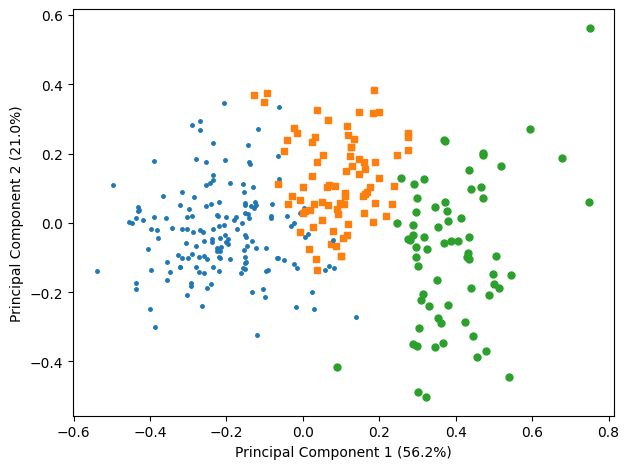

In [16]:
display_results_fuzzy_partition(X, scad2_models, numeric_labels)

# IFWFCM - Xing et al. 2014

In [17]:
%%capture
ifwfcm_models = np.array([])
for i in range(10):
    model = ifwfcm_xing2014(X, c, verbose=True, init="None")
    ifwfcm_models = np.append(ifwfcm_models, model)
ifwfcm_models = sorted(ifwfcm_models, key=lambda model: model['obj_func'])

J values: [0.24044221275083016, 0.24050338204698757, 0.24055208552997462, 0.2405810609825451, 0.24070655268007823, 0.24072420720135485, 0.24084378004167817, 0.24102503454990057, 0.24153930597387208, 0.24155295164400772]
ARI values: [0.24212467448807806, 0.24212467448807806, 0.2536579511767504, 0.2571445330809179, 0.24882391490120656, 0.25068339573260046, 0.25068339573260046, 0.26088765539008363, 0.26413981544537446, 0.2668088153319295]
NMI values: [0.34262954574679405, 0.34262954574679405, 0.3568044132010884, 0.3562970287023804, 0.3426956183387115, 0.3543708826257902, 0.3543708826257902, 0.35372480986057536, 0.34928611917722513, 0.35127732920781285]


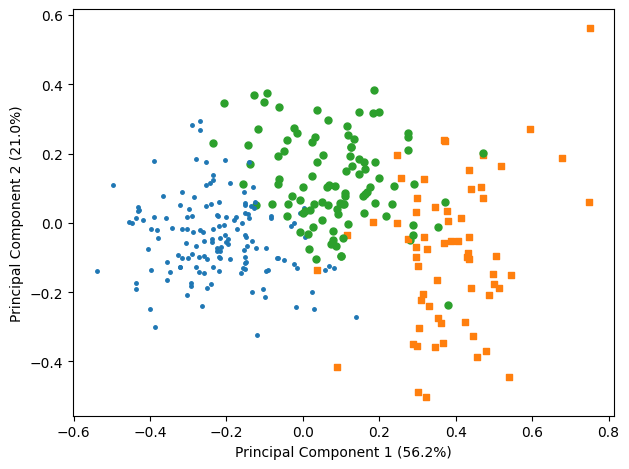

In [18]:
display_results_fuzzy_partition(X, ifwfcm_models, numeric_labels)

# IFWFCM_KD Xing 2014

In [19]:
%%capture
ifwfcm_kd_models = np.array([])
for i in range(10):
    model = ifwfcm_kd_xing2014(X, c, verbose=True, init="None")
    ifwfcm_kd_models = np.append(ifwfcm_kd_models, model)
ifwfcm_kd_models = sorted(ifwfcm_kd_models, key=lambda model: model['obj_func'])

J values: [4.527768914011849, 4.527959131674193, 4.528046935393916, 4.528104335904951, 4.528122247578254, 4.528238410983118, 4.528247358279198, 4.528350697515413, 4.528369443403194, 4.528558145319289]
ARI values: [0.37315172186291673, 0.37315172186291673, 0.37315172186291673, 0.37315172186291673, 0.37315172186291673, 0.37315172186291673, 0.37315172186291673, 0.37315172186291673, 0.37315172186291673, 0.37315172186291673]
NMI values: [0.4835737963048288, 0.4835737963048288, 0.4835737963048288, 0.4835737963048288, 0.4835737963048288, 0.4835737963048288, 0.4835737963048288, 0.4835737963048288, 0.4835737963048288, 0.48357379630482883]


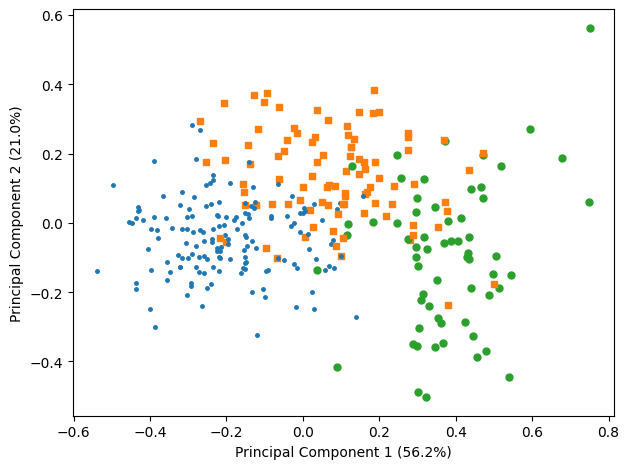

In [20]:
display_results_fuzzy_partition(X, ifwfcm_kd_models, numeric_labels)